In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("/content/results", exist_ok=True)

abundance = pd.read_csv("/content/abundance_raw.csv")
meta = pd.read_csv("/content/metadata_raw.csv")

SUBJECT_COL = "subject_id"
SITE_COL = "body_site"
LABEL_COL = "age_category"
SAMPLE_ID_COL = "sample_id"
SITES_TO_USE = ["stool", "oralcavity"]

meta_filtered = meta[meta[SITE_COL].isin(SITES_TO_USE)].copy()
meta_filtered = meta_filtered.sort_values(SAMPLE_ID_COL).drop_duplicates(subset=[SUBJECT_COL, SITE_COL], keep="first")
site_counts = meta_filtered.groupby(SUBJECT_COL)[SITE_COL].nunique()
complete_subjects = site_counts[site_counts == len(SITES_TO_USE)].index.tolist()
meta_complete = meta_filtered[meta_filtered[SUBJECT_COL].isin(complete_subjects)].copy()
print(f"Ferretti: {len(complete_subjects)} matched subjects")
print(meta_complete.groupby([SUBJECT_COL])[LABEL_COL].first().value_counts())

Ferretti: 44 matched subjects
age_category
newborn    23
adult      21
Name: count, dtype: int64


In [ ]:
def build_site_table(site_name, meta_df, abundance_df):
    site_meta = meta_df[meta_df[SITE_COL] == site_name][[SUBJECT_COL, SAMPLE_ID_COL, LABEL_COL]]
    merged = site_meta.merge(abundance_df, on=SAMPLE_ID_COL, how="left")
    merged = merged.set_index(SUBJECT_COL)
    labels = merged[LABEL_COL]
    features = merged.drop(columns=[SAMPLE_ID_COL, LABEL_COL])
    features = features.select_dtypes(include=[np.number])
    return features, labels

def clr_transform(df, pseudocount=1e-6):
    df = df + pseudocount
    log_df = np.log(df)
    gm = log_df.mean(axis=1)
    return log_df.sub(gm, axis=0)

def filter_low_variance(df, min_variance=1e-4):
    variances = df.var(axis=0)
    return df[variances[variances > min_variance].index]

site_tables = {}
site_labels = {}
for site in SITES_TO_USE:
    feats, labs = build_site_table(site, meta_complete, abundance)
    site_tables[site] = feats
    site_labels[site] = labs
    print(f"{site}: {feats.shape[0]} subjects, {feats.shape[1]} taxa (before filtering)")

site_tables_clr = {}
for site in SITES_TO_USE:
    filtered = filter_low_variance(site_tables[site])
    site_tables_clr[site] = clr_transform(filtered)

common_subjects = set(site_tables_clr[SITES_TO_USE[0]].index)
for site in SITES_TO_USE[1:]:
    common_subjects &= set(site_tables_clr[site].index)
common_subjects = sorted(common_subjects)

for site in SITES_TO_USE:
    site_tables_clr[site] = site_tables_clr[site].loc[common_subjects]

y = site_labels[SITES_TO_USE[0]].loc[common_subjects]
y_binary = (y.astype(str).str.lower() == "adult").astype(int)

from itertools import combinations
conditions = {}
for site in SITES_TO_USE:
    conditions[site] = site_tables_clr[site]
all_name = "+".join(SITES_TO_USE)
conditions[all_name] = pd.concat([site_tables_clr[s].add_prefix(f"{s}__") for s in SITES_TO_USE], axis=1)

print(f"\\nFerretti final aligned subjects: {len(common_subjects)}")
for name, df in conditions.items():
    print(f"  {name}: {df.shape}")

stool: 44 subjects, 667 taxa (before filtering)
oralcavity: 44 subjects, 667 taxa (before filtering)
\nFerretti final aligned subjects: 44
  stool: (44, 291)
  oralcavity: (44, 153)
  stool+oralcavity: (44, 444)


In [ ]:
!pip install xgboost shap -q

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import shap
import warnings
warnings.filterwarnings("ignore")

models = {
    "LogReg_L1": Pipeline([("scale", StandardScaler()), ("clf", LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000, random_state=42))]),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=3, use_label_encoder=False, eval_metric="logloss", random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for cond_name, X in conditions.items():
    X_clean = X.fillna(0)
    for model_name, model in models.items():
        scores = cross_val_score(model, X_clean, y_binary, cv=cv, scoring="roc_auc")
        results.append({"condition": cond_name, "model": model_name, "mean_auc": scores.mean(), "std_auc": scores.std()})

results_df = pd.DataFrame(results)
print("Ferretti results:")
print(results_df)

Ferretti results:
          condition         model  mean_auc  std_auc
0             stool     LogReg_L1     0.990  0.02000
1             stool  RandomForest     1.000  0.00000
2             stool       XGBoost     0.960  0.04899
3        oralcavity     LogReg_L1     0.970  0.04000
4        oralcavity  RandomForest     0.975  0.05000
5        oralcavity       XGBoost     0.975  0.05000
6  stool+oralcavity     LogReg_L1     1.000  0.00000
7  stool+oralcavity  RandomForest     1.000  0.00000
8  stool+oralcavity       XGBoost     0.960  0.04899


## SHAP site-contribution on the Ferretti fused model (reference point for comparison)

In [ ]:
def get_site_contribution(conditions_dict, y_binary_series, sites_list, fused_name):
    """Trains a Random Forest on the fused condition and returns total SHAP importance per site."""
    X_fused = conditions_dict[fused_name].fillna(0)
    model = RandomForestClassifier(n_estimators=300, random_state=42)
    model.fit(X_fused, y_binary_series)
    explainer = shap.TreeExplainer(model)
    raw_shap = explainer.shap_values(X_fused)

    if isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
        shap_matrix = raw_shap[:, :, 1]
    elif isinstance(raw_shap, list):
        shap_matrix = np.array(raw_shap[1])
    elif hasattr(raw_shap, "values"):
        vals = raw_shap.values
        shap_matrix = vals[:, :, 1] if vals.ndim == 3 else vals
    else:
        shap_matrix = np.array(raw_shap)

    mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
    feature_names = X_fused.columns
    site_importance = {}
    for site in sites_list:
        prefix = f"{site}__"
        idx = [i for i, f in enumerate(feature_names) if f.startswith(prefix)]
        site_importance[site] = mean_abs_shap[idx].sum() if idx else 0
    return site_importance, shap_matrix, X_fused

ferretti_site_importance, ferretti_shap_matrix, ferretti_X_fused = get_site_contribution(
    conditions, y_binary, SITES_TO_USE, "+".join(SITES_TO_USE)
)
total = sum(ferretti_site_importance.values())
print("Ferretti (n=44) site contribution:")
for site, val in ferretti_site_importance.items():
    print(f"  {site}: {val/total*100:.1f}%")

Ferretti (n=44) site contribution:
  stool: 41.8%
  oralcavity: 58.2%


In [ ]:
r_check = '''
suppressMessages(library(curatedMetagenomicData))
all_data <- sampleMetadata
print(unique(all_data$study_name))
'''
with open("/content/check_datasets.R", "w") as f:
    f.write(r_check)
!/usr/local/miniconda3/bin/Rscript /content/check_datasets.R

 [1] "AsnicarF_2017"          "AsnicarF_2021"          "BackhedF_2015"         
 [4] "BedarfJR_2017"          "Bengtsson-PalmeJ_2015"  "BritoIL_2016"          
 [7] "BrooksB_2017"           "Castro-NallarE_2015"    "ChengpingW_2017"       
[10] "ChngKR_2016"            "ChuDM_2017"             "CosteaPI_2017"         
[13] "DavidLA_2015"           "DeFilippisF_2019"       "DhakanDB_2019"         
[16] "FengQ_2015"             "FerrettiP_2018"         "FrankelAE_2017"        
[19] "GhensiP_2019"           "GopalakrishnanV_2018"   "GuptaA_2019"           
[22] "HallAB_2017"            "HanniganGD_2017"        "HansenLBS_2018"        
[25] "Heitz-BuschartA_2016"   "HMP_2012"               "HMP_2019_ibdmdb"       
[28] "HMP_2019_t2d"           "IaniroG_2022"           "IjazUZ_2017"           
[31] "JieZ_2017"              "KarlssonFH_2013"        "KaurK_2020"            
[34] "KeohaneDM_2020"         "KieserS_2018"           "KosticAD_2015"         
[37] "LassalleF_2017"         "LeChateli

In [ ]:
r_check2 = '''
suppressMessages(library(curatedMetagenomicData))
meta <- sampleMetadata

# Check HMP_2012
hmp <- meta[meta$study_name == "HMP_2012", ]
cat("HMP_2012 body sites:\\n")
print(table(hmp$body_site))
cat("\\nHMP_2012 subject count:", length(unique(hmp$subject_id)), "\\n")

# Check BritoIL_2016
brito <- meta[meta$study_name == "BritoIL_2016", ]
cat("\\nBritoIL_2016 body sites:\\n")
print(table(brito$body_site))
cat("\\nBritoIL_2016 subject count:", length(unique(brito$subject_id)), "\\n")
'''
with open("/content/check_candidates.R", "w") as f:
    f.write(r_check2)
!/usr/local/miniconda3/bin/Rscript /content/check_candidates.R

HMP_2012 body sites:

nasalcavity  oralcavity        skin       stool      vagina 
         93         414          27         147          67 

HMP_2012 subject count: 103 

BritoIL_2016 body sites:

oralcavity      stool 
       140        172 

BritoIL_2016 subject count: 172 


In [ ]:
r_check3 = '''
suppressMessages(library(curatedMetagenomicData))
meta <- sampleMetadata
brito <- meta[meta$study_name == "BritoIL_2016", ]
cat("Available columns:\\n")
print(names(brito))
cat("\\nstudy_condition values:\\n")
print(table(brito$study_condition, useNA="always"))
cat("\\nage_category values:\\n")
print(table(brito$age_category, useNA="always"))
cat("\\ndisease values:\\n")
print(table(brito$disease, useNA="always"))
cat("\\ngender values:\\n")
print(table(brito$gender, useNA="always"))
'''
with open("/content/check_brito.R", "w") as f:
    f.write(r_check3)
!/usr/local/miniconda3/bin/Rscript /content/check_brito.R

Available columns:
  [1] "study_name"                         "sample_id"                         
  [3] "subject_id"                         "body_site"                         
  [5] "antibiotics_current_use"            "study_condition"                   
  [7] "disease"                            "age"                               
  [9] "infant_age"                         "age_category"                      
 [11] "gender"                             "country"                           
 [13] "non_westernized"                    "sequencing_platform"               
 [15] "DNA_extraction_kit"                 "PMID"                              
 [17] "number_reads"                       "number_bases"                      
 [19] "minimum_read_length"                "median_read_length"                
 [21] "NCBI_accession"                     "pregnant"                          
 [23] "lactating"                          "curator"                           
 [25] "BMI"          

In [ ]:
r_script_nagata = '''
suppressMessages(library(curatedMetagenomicData))
suppressMessages(library(SummarizedExperiment))

se_list <- curatedMetagenomicData("BritoIL_2016.relative_abundance", dryrun = FALSE)
se <- se_list[[1]]

abundance <- as.data.frame(t(assay(se)))
abundance$sample_id <- rownames(abundance)

meta <- as.data.frame(colData(se))
meta$sample_id <- rownames(meta)

write.csv(abundance, "/content/brito_abundance_raw.csv", row.names = FALSE)
write.csv(meta, "/content/brito_metadata_raw.csv", row.names = FALSE)
cat("Exported", nrow(abundance), "samples and", ncol(abundance)-1, "taxa.\\n")
'''
with open("/content/fetch_nagata.R", "w") as f:
    f.write(r_script_nagata)
!/usr/local/miniconda3/bin/Rscript /content/fetch_nagata.R


$`2021-03-31.BritoIL_2016.relative_abundance`
dropping rows without rowTree matches:
  k__Bacteria|p__Actinobacteria|c__Coriobacteriia|o__Coriobacteriales|f__Atopobiaceae|g__Olsenella|s__Olsenella_profusa
  k__Bacteria|p__Actinobacteria|c__Coriobacteriia|o__Coriobacteriales|f__Coriobacteriaceae|g__Collinsella|s__Collinsella_stercoris
  k__Bacteria|p__Actinobacteria|c__Coriobacteriia|o__Coriobacteriales|f__Coriobacteriaceae|g__Enorma|s__[Collinsella]_massiliensis
  k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Bacillales_unclassified|g__Gemella|s__Gemella_bergeri
  k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Carnobacteriaceae|g__Granulicatella|s__Granulicatella_elegans
  k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__Ruminococcus|s__Ruminococcus_champanellensis
  k__Bacteria|p__Firmicutes|c__Erysipelotrichia|o__Erysipelotrichales|f__Erysipelotrichaceae|g__Bulleidia|s__Bulleidia_extructa
  k__Bacteria|p__Proteobacteria|c__Betaproteo

In [ ]:
nagata_abundance = pd.read_csv("/content/brito_abundance_raw.csv")
nagata_meta = pd.read_csv("/content/brito_metadata_raw.csv")

print("Brito metadata columns:", list(nagata_meta.columns))
print("\\nBody site column values:")
site_col_guess = [c for c in nagata_meta.columns if 'body' in c.lower() or 'site' in c.lower()]
print("Likely body-site column(s):", site_col_guess)
if site_col_guess:
    print(nagata_meta[site_col_guess[0]].value_counts())

print("\\nPotential classification target columns (check these for usable labels):")
for col in ["disease", "study_condition", "age_category", "gender", "BMI", "disease_subtype"]:
    if col in nagata_meta.columns:
        print(f"\\n{col}:")
        print(nagata_meta[col].value_counts(dropna=False).head(10))

Brito metadata columns: ['study_name', 'subject_id', 'body_site', 'study_condition', 'disease', 'age', 'age_category', 'gender', 'country', 'non_westernized', 'sequencing_platform', 'DNA_extraction_kit', 'PMID', 'number_reads', 'number_bases', 'minimum_read_length', 'median_read_length', 'NCBI_accession', 'curator', 'family', 'location', 'sample_id']
\nBody site column values:
Likely body-site column(s): ['body_site']
body_site
stool         172
oralcavity    140
Name: count, dtype: int64
\nPotential classification target columns (check these for usable labels):
\ndisease:
disease
healthy    312
Name: count, dtype: int64
\nstudy_condition:
study_condition
control    312
Name: count, dtype: int64
\nage_category:
age_category
adult        259
schoolage     25
senior        18
child         10
Name: count, dtype: int64
\ngender:
gender
female    169
male      143
Name: count, dtype: int64


In [ ]:
NAGATA_SUBJECT_COL = "subject_id"
NAGATA_SITE_COL = "body_site"
NAGATA_LABEL_COL = "gender"
NAGATA_SAMPLE_ID_COL = "sample_id"

nagata_meta_filtered = nagata_meta[nagata_meta[NAGATA_SITE_COL].isin(["stool", "oralcavity"])].copy()
nagata_meta_filtered = nagata_meta_filtered.sort_values(NAGATA_SAMPLE_ID_COL).drop_duplicates(
    subset=[NAGATA_SUBJECT_COL, NAGATA_SITE_COL], keep="first"
)
nagata_site_counts = nagata_meta_filtered.groupby(NAGATA_SUBJECT_COL)[NAGATA_SITE_COL].nunique()
nagata_complete_subjects = nagata_site_counts[nagata_site_counts == 2].index.tolist()
nagata_meta_complete = nagata_meta_filtered[nagata_meta_filtered[NAGATA_SUBJECT_COL].isin(nagata_complete_subjects)].copy()

print(f"Brito: {len(nagata_complete_subjects)} matched subjects (both sites present)")
print(nagata_meta_complete.groupby([NAGATA_SUBJECT_COL])[NAGATA_LABEL_COL].first().value_counts(dropna=False))

Brito: 140 matched subjects (both sites present)
gender
female    74
male      66
Name: count, dtype: int64


In [ ]:
NAGATA_SITES_TO_USE = ["stool", "oralcavity"]
NAGATA_TARGET_VALUE = "female"

##  Build feature tables, preprocess, fuse, and classify

In [ ]:
nagata_site_tables = {}
nagata_site_labels = {}
for site in NAGATA_SITES_TO_USE:
    feats, labs = build_site_table(site, nagata_meta_complete, nagata_abundance)
    labs = nagata_meta_complete[nagata_meta_complete[NAGATA_SITE_COL] == site].set_index(NAGATA_SUBJECT_COL)[NAGATA_LABEL_COL]
    nagata_site_tables[site] = feats
    nagata_site_labels[site] = labs
    print(f"{site}: {feats.shape[0]} subjects, {feats.shape[1]} taxa (before filtering)")

nagata_site_tables_clr = {}
for site in NAGATA_SITES_TO_USE:
    filtered = filter_low_variance(nagata_site_tables[site])
    nagata_site_tables_clr[site] = clr_transform(filtered)

nagata_common_subjects = set(nagata_site_tables_clr[NAGATA_SITES_TO_USE[0]].index)
for site in NAGATA_SITES_TO_USE[1:]:
    nagata_common_subjects &= set(nagata_site_tables_clr[site].index)
nagata_common_subjects = sorted(nagata_common_subjects)

for site in NAGATA_SITES_TO_USE:
    nagata_site_tables_clr[site] = nagata_site_tables_clr[site].loc[nagata_common_subjects]

nagata_y_raw = nagata_site_labels[NAGATA_SITES_TO_USE[0]].loc[nagata_common_subjects]
print("\nFinal label distribution:")
print(nagata_y_raw.value_counts(dropna=False))

NAGATA_TARGET_VALUE = "female"
nagata_y_binary = (nagata_y_raw == NAGATA_TARGET_VALUE).astype(int)
print(f"\nUsing '{NAGATA_TARGET_VALUE}' as positive class. Balance: {nagata_y_binary.value_counts().to_dict()}")

nagata_conditions = {}
for site in NAGATA_SITES_TO_USE:
    nagata_conditions[site] = nagata_site_tables_clr[site]
nagata_fused_name = "+".join(NAGATA_SITES_TO_USE)
nagata_conditions[nagata_fused_name] = pd.concat(
    [nagata_site_tables_clr[s].add_prefix(f"{s}__") for s in NAGATA_SITES_TO_USE], axis=1
)

print(f"\nBrito final aligned subjects: {len(nagata_common_subjects)}")
for name, df in nagata_conditions.items():
    print(f"  {name}: {df.shape}")

stool: 140 subjects, 730 taxa (before filtering)
oralcavity: 140 subjects, 730 taxa (before filtering)

Final label distribution:
gender
female    74
male      66
Name: count, dtype: int64

Using 'female' as positive class. Balance: {1: 74, 0: 66}

Brito final aligned subjects: 140
  stool: (140, 227)
  oralcavity: (140, 269)
  stool+oralcavity: (140, 496)


In [ ]:
nagata_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
nagata_results = []
for cond_name, X in nagata_conditions.items():
    X_clean = X.fillna(0)
    for model_name, model in models.items():
        try:
            scores = cross_val_score(model, X_clean, nagata_y_binary, cv=nagata_cv, scoring="roc_auc")
            nagata_results.append({"condition": cond_name, "model": model_name, "mean_auc": scores.mean(), "std_auc": scores.std()})
        except Exception as e:
            print(f"SKIPPED {cond_name}/{model_name}: {e}")

nagata_results_df = pd.DataFrame(nagata_results)
print("Nagata replication results:")
print(nagata_results_df)
nagata_results_df.to_csv("/content/results/nagata_condition_scores.csv", index=False)

Nagata replication results:
          condition         model  mean_auc   std_auc
0             stool     LogReg_L1  0.561366  0.118615
1             stool  RandomForest  0.599152  0.140117
2             stool       XGBoost  0.565269  0.164179
3        oralcavity     LogReg_L1  0.533925  0.074417
4        oralcavity  RandomForest  0.628608  0.036665
5        oralcavity       XGBoost  0.608561  0.038996
6  stool+oralcavity     LogReg_L1  0.545107  0.093553
7  stool+oralcavity  RandomForest  0.615670  0.061409
8  stool+oralcavity       XGBoost  0.600345  0.104549


## SHAP site-contribution on the Brito fused model

Brito (n=140) site contribution:
  stool: 39.4%
  oralcavity: 60.6%


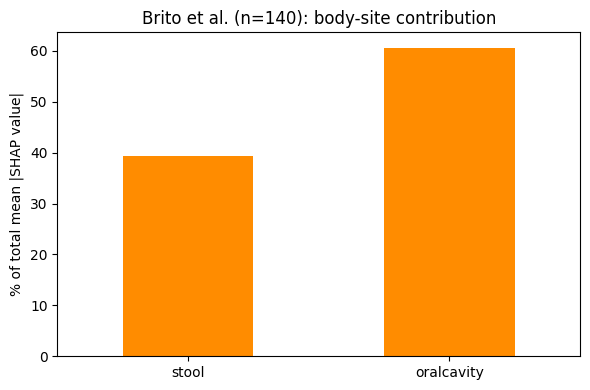

In [ ]:
nagata_site_importance, nagata_shap_matrix, nagata_X_fused = get_site_contribution(
    nagata_conditions, nagata_y_binary, NAGATA_SITES_TO_USE, nagata_fused_name
)
nagata_total = sum(nagata_site_importance.values())
print("Brito (n={}) site contribution:".format(len(nagata_common_subjects)))
for site, val in nagata_site_importance.items():
    print(f"  {site}: {val/nagata_total*100:.1f}%")

plt.figure(figsize=(6,4))
pd.Series({k: v/nagata_total*100 for k, v in nagata_site_importance.items()}).plot(kind="bar", color="darkorange")
plt.ylabel("% of total mean |SHAP value|")
plt.title(f"Brito et al. (n={len(nagata_common_subjects)}): body-site contribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/results/brito_site_contribution.png", dpi=150)
plt.show()

In [ ]:
def site_split_permutation_test(X_fused, y_binary_series, sites_list, real_importance, n_permutations=200, seed=42):
    """
    Null hypothesis: the split of SHAP importance between sites is no different from what
    you'd get by randomly relabeling which features 'belong' to which site (keeping the
    same number of features per site, but scrambling which specific columns are grouped
    together). This tests whether the observed asymmetry reflects real site-level structure
    rather than being an artifact of a few individually strong features landing on one side.
    """
    rng = np.random.RandomState(seed)
    feature_names = list(X_fused.columns)
    site_sizes = {}
    for site in sites_list:
        prefix = f"{site}__"
        site_sizes[site] = sum(1 for f in feature_names if f.startswith(prefix))

    model = RandomForestClassifier(n_estimators=300, random_state=42)
    model.fit(X_fused, y_binary_series)
    explainer = shap.TreeExplainer(model)
    raw_shap = explainer.shap_values(X_fused)
    if isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
        shap_matrix = raw_shap[:, :, 1]
    elif isinstance(raw_shap, list):
        shap_matrix = np.array(raw_shap[1])
    elif hasattr(raw_shap, "values"):
        vals = raw_shap.values
        shap_matrix = vals[:, :, 1] if vals.ndim == 3 else vals
    else:
        shap_matrix = np.array(raw_shap)

    mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
    n_features = len(feature_names)

    real_total = sum(real_importance.values())
    real_pct = {s: real_importance[s] / real_total * 100 for s in sites_list}
    real_max_pct = max(real_pct.values())

    null_max_pcts = []
    all_idx = np.arange(n_features)
    for i in range(n_permutations):
        shuffled_idx = rng.permutation(all_idx)
        pos = 0
        perm_importance = {}
        for site in sites_list:
            size = site_sizes[site]
            idx_for_site = shuffled_idx[pos:pos+size]
            perm_importance[site] = mean_abs_shap[idx_for_site].sum()
            pos += size
        perm_total = sum(perm_importance.values())
        perm_pct = {s: perm_importance[s] / perm_total * 100 for s in sites_list}
        null_max_pcts.append(max(perm_pct.values()))

    null_max_pcts = np.array(null_max_pcts)
    p_value = (null_max_pcts >= real_max_pct).mean()

    return {
        "real_split_pct": real_pct,
        "real_max_pct": real_max_pct,
        "null_mean_max_pct": null_max_pcts.mean(),
        "null_std_max_pct": null_max_pcts.std(),
        "p_value": p_value,
        "null_distribution": null_max_pcts
    }

print("Running permutation test on Ferretti site-contribution split...")
ferretti_perm_result = site_split_permutation_test(
    ferretti_X_fused, y_binary, SITES_TO_USE, ferretti_site_importance, n_permutations=200
)
print(f"Real split: {ferretti_perm_result['real_split_pct']}")
print(f"Real max site share: {ferretti_perm_result['real_max_pct']:.1f}%")
print(f"Null distribution: mean = {ferretti_perm_result['null_mean_max_pct']:.1f}%, std = {ferretti_perm_result['null_std_max_pct']:.1f}%")
print(f"P-value: {ferretti_perm_result['p_value']:.4f}")

Running permutation test on Ferretti site-contribution split...
Real split: {'stool': np.float64(41.839933416310295), 'oralcavity': np.float64(58.160066583689705)}
Real max site share: 58.2%
Null distribution: mean = 65.4%, std = 5.5%
P-value: 0.8900


In [ ]:
print("Running permutation test on Brito site-contribution split...")
nagata_perm_result = site_split_permutation_test(
    nagata_X_fused, nagata_y_binary, NAGATA_SITES_TO_USE, nagata_site_importance, n_permutations=200
)
print(f"Real split: {nagata_perm_result['real_split_pct']}")
print(f"Real max site share: {nagata_perm_result['real_max_pct']:.1f}%")
print(f"Null distribution: mean = {nagata_perm_result['null_mean_max_pct']:.1f}%, std = {nagata_perm_result['null_std_max_pct']:.1f}%")
print(f"P-value: {nagata_perm_result['p_value']:.4f}")

Running permutation test on Brito site-contribution split...
Real split: {'stool': np.float64(39.401537353843366), 'oralcavity': np.float64(60.59846264615665)}
Real max site share: 60.6%
Null distribution: mean = 54.5%, std = 2.0%
P-value: 0.0000


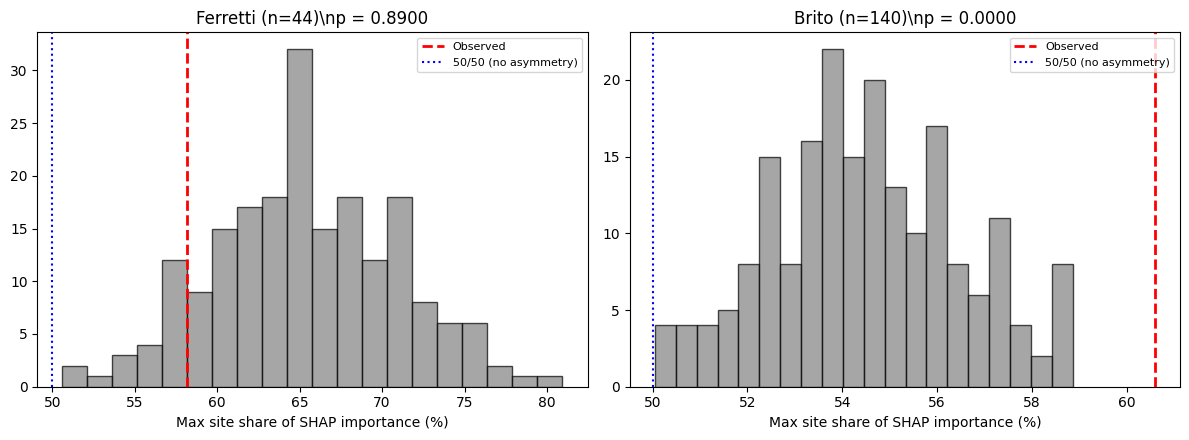

\nInterpretation guide:
- A LOW p-value (e.g. < 0.05) means the observed site-contribution asymmetry is unlikely under random feature-to-site reassignment,
  i.e. real site-level structure, not just a few strong individual features.
- If BOTH cohorts show low p-values, that's a much stronger claim than either alone: the site-attribution
  asymmetry is a real, replicable phenomenon, not a quirk of one small dataset.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(ferretti_perm_result["null_distribution"], bins=20, color="gray", edgecolor="black", alpha=0.7)
axes[0].axvline(ferretti_perm_result["real_max_pct"], color="red", linestyle="--", linewidth=2, label="Observed")
axes[0].axvline(50, color="blue", linestyle=":", label="50/50 (no asymmetry)")
axes[0].set_title(f"Ferretti (n=44)\\np = {ferretti_perm_result['p_value']:.4f}")
axes[0].set_xlabel("Max site share of SHAP importance (%)")
axes[0].legend(fontsize=8)

axes[1].hist(nagata_perm_result["null_distribution"], bins=20, color="gray", edgecolor="black", alpha=0.7)
axes[1].axvline(nagata_perm_result["real_max_pct"], color="red", linestyle="--", linewidth=2, label="Observed")
axes[1].axvline(50, color="blue", linestyle=":", label="50/50 (no asymmetry)")
axes[1].set_title(f"Brito (n={len(nagata_common_subjects)})\\np = {nagata_perm_result['p_value']:.4f}")
axes[1].set_xlabel("Max site share of SHAP importance (%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("/content/results/permutation_test_comparison.png", dpi=150)
plt.show()

print("\\nInterpretation guide:")
print("- A LOW p-value (e.g. < 0.05) means the observed site-contribution asymmetry is unlikely under random feature-to-site reassignment,")
print("  i.e. real site-level structure, not just a few strong individual features.")
print("- If BOTH cohorts show low p-values, that's a much stronger claim than either alone: the site-attribution")
print("  asymmetry is a real, replicable phenomenon, not a quirk of one small dataset.")

In [ ]:
import json

summary = {
    "ferretti": {
        "n_subjects": len(common_subjects),
        "site_contribution_pct": {k: v/total*100 for k, v in ferretti_site_importance.items()},
        "permutation_p_value": ferretti_perm_result["p_value"],
    },
    "brito": {
        "n_subjects": len(nagata_common_subjects),
        "label_used": str(NAGATA_LABEL_COL),
        "target_value": str(NAGATA_TARGET_VALUE),
        "site_contribution_pct": {k: v/nagata_total*100 for k, v in nagata_site_importance.items()},
        "permutation_p_value": nagata_perm_result["p_value"],
    }
}

with open("/content/results/replication_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

import shutil
shutil.make_archive("/content/replication_results", "zip", "/content/results")
print("\nSaved: /content/replication_results.zip")

{
  "ferretti": {
    "n_subjects": 44,
    "site_contribution_pct": {
      "stool": 41.839933416310295,
      "oralcavity": 58.160066583689705
    },
    "permutation_p_value": 0.89
  },
  "brito": {
    "n_subjects": 140,
    "label_used": "gender",
    "target_value": "female",
    "site_contribution_pct": {
      "stool": 39.401537353843366,
      "oralcavity": 60.59846264615665
    },
    "permutation_p_value": 0.0
  }
}

Saved: /content/replication_results.zip
